# Project Modern Clustering: Expert Discovery System and Collaboration Network Analysis with HORUS data

# 1. Setup and imports

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display
from tqdm.auto import tqdm
import torch
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import ParameterGrid
import time
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
import nltk
from nltk.corpus import stopwords

### 1.1. Environment Configuration (Mounting Drive)

In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    base_path = Path("/content/drive/Shareddrives/Minería/proyecto_horus/data")
    # base_path = Path("/content/drive/MyDrive/proyecto_horus/data")
else:
    base_path = Path("../data/")

df = pd.read_parquet(base_path / "processed/products_modeling.parquet")

# 2. Check of text length before embed phase

In [3]:
text_lengths = df['embeddings_text'].str.len()

# Samples of the longest values
print("\nTop 5 longest samples:")
longest_samples = df.loc[text_lengths.sort_values(ascending=False).index[:5], ['embeddings_text']]
longest_samples['char_count'] = longest_samples['embeddings_text'].str.len()
display(longest_samples)


Top 5 longest samples:


,embeddings_text,char_count
18382,[Odontología] Proyecto: Condición periodontal ...,23070
31343,[Ciencias] Tesis Doctorado: Effect of mercury ...,22710
24981,[Medicina] Tesis Maestría: Determinación de lo...,22546
51651,[Medicina] Tesis Doctorado: Impacto de la vacu...,20396
0,[Ciencias Económicas] Artículo de revista: La ...,16360


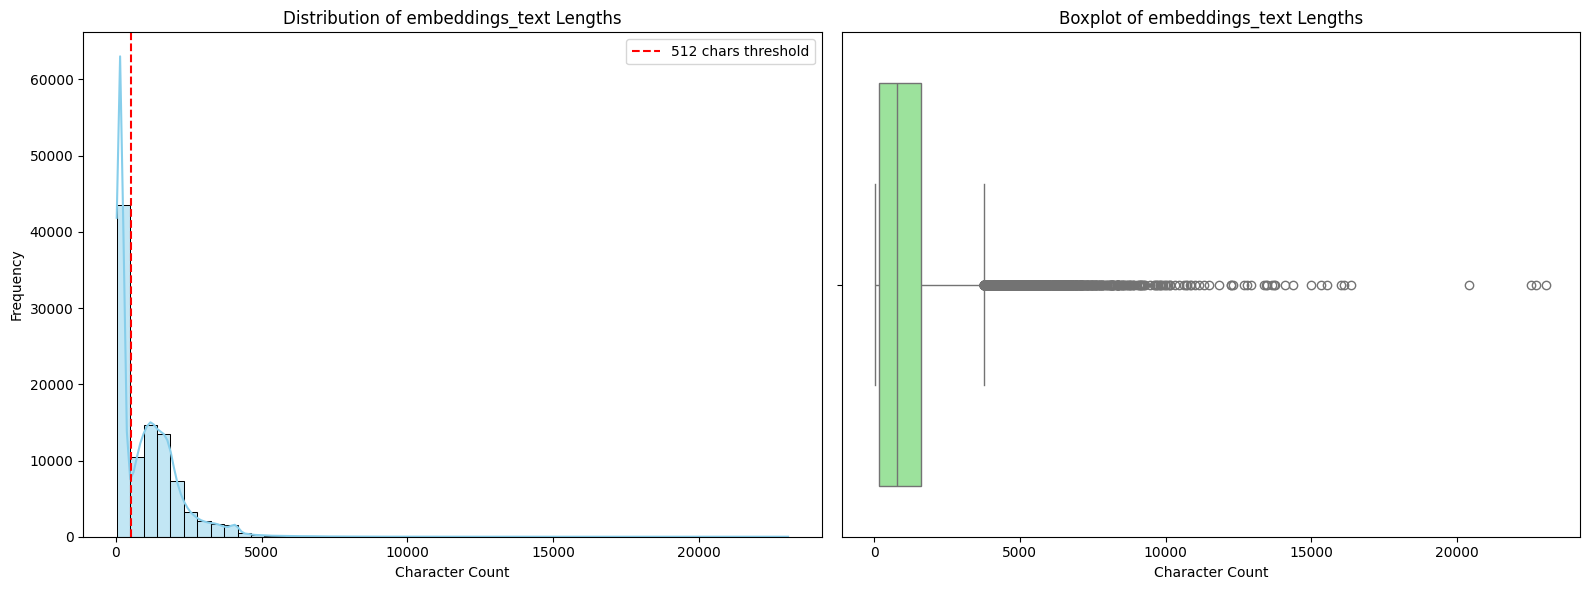

In [4]:
# Calculate lengths
text_lengths = df['embeddings_text'].str.len()

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram (Distribution)
sns.histplot(text_lengths, bins=50, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribution of embeddings_text Lengths')
ax1.set_xlabel('Character Count')
ax1.set_ylabel('Frequency')
ax1.axvline(512, color='red', linestyle='--', label='512 chars threshold')
ax1.legend()

# 2. Boxplot (Outliers/Quartiles)
sns.boxplot(x=text_lengths, ax=ax2, color='lightgreen')
ax2.set_title('Boxplot of embeddings_text Lengths')
ax2.set_xlabel('Character Count')

plt.tight_layout()
plt.show()

In [5]:
# 1. Calculate the character length of each row
df['text_length'] = df['embeddings_text'].astype(str).str.len()

# 2. Get detailed percentiles to see exactly where the tail gets long
stats = df['text_length'].describe(percentiles=[.25, .5, .75, .90, .95, .98, .99])

# 3. Calculate the specific proportion of your >4000 outliers
outlier_threshold = 4000
outlier_count = len(df[df['text_length'] > outlier_threshold])
total_count = len(df)
outlier_percentage = (outlier_count / total_count) * 100

print("--- Distribution Stats ---")
print(stats.round(2))
print(f"\nTotal rows > {outlier_threshold} chars: {outlier_count} ({outlier_percentage:.2f}%)")

--- Distribution Stats ---
count    99064.00
mean      1028.62
std       1087.10
min         30.00
25%        150.00
50%        794.00
75%       1600.00
90%       2307.00
95%       3103.00
98%       3996.00
99%       4337.37
max      23070.00
Name: text_length, dtype: float64

Total rows > 4000 chars: 1970 (1.99%)


In [6]:
# 1. Grab 2 random samples from the "normal" (interquartile) range
normal_samples = df[(df['text_length'] >= stats['25%']) & (df['text_length'] <= stats['75%'])]['embeddings_text'].sample(2, random_state=42)

print("--- Normal Samples ---")
for i, text in enumerate(normal_samples):
    print(f"Sample {i+1} (Len: {len(str(text))}): {text}")

# 2. Grab 2 random samples from the >4000 outlier range
# We will truncate them to 500 characters so they don't flood your screen or the prompt
outlier_samples = df[df['text_length'] > 4000]['embeddings_text'].sample(2, random_state=42)

print("\n--- Outlier Samples (Truncated) ---")
for i, text in enumerate(outlier_samples):
    print(f"Sample {i+1} (Len: {len(str(text))}): {str(text)[:512]}... [TRUNCATED]")

--- Normal Samples ---
Sample 1 (Len: 1252): [Ingeniería] Tesis Maestría: Desarrollo de un método químico para recuperación de crudo a partir de las borras generadas en los procesos de mantenimiento de tanques y tuberías en distritos de producción petroleros de Colombia. Este trabajo desarrolla un método químico que permite recuperar el crudo de las borras generadas en los procesos de mantenimiento de tanques y tuberías, de tal forma que pueda ser inyectado nuevamente a las líneas de bombeo. Se trabaja con muestras provenientes de crudos parafínicos, nafténicos y con alto contenido de sedimentos, provenientes de distritos de producción petrolero en Colombia. Se logra desarrollar dos procedimientos para el tratamiento de la borra: a) para las borras generadas por emulsión de crudo, agua y sedimento, se obtiene un procedimiento químico que permite el rompimiento de la emulsión, a eficiencias superiores al 95% tanto de remoción de agua como de sedimentos; b) para el caso de la formación d

# 3. Embed phase (ran in colab with T4 GPU)

## 3.1. Set Up the Resilient Directory Structure

In [4]:
# --- CONFIGURATION ---
# Double-check that Colab actually provided a GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on: {device.upper()}")

DRIVE_SAVE_DIR = base_path / 'embeddings_chunks/'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

Running on: CUDA


## 3.2. Prepare and sort data

In [5]:
print("Calculating lengths and sorting...")
# We MUST save the original index so we can put the embeddings back in order later
df['text_length'] = df['embeddings_text'].str.len()
df_sorted = df.sort_values('text_length', ascending=False).reset_index(drop=False)

texts_to_embed = df_sorted['embeddings_text'].tolist()
total_texts = len(texts_to_embed)
print(f"Total texts to embed: {total_texts}")

Calculating lengths and sorting...
Total texts to embed: 99064


## 3.3. Load the Model

In [6]:
print("Loading model...")

# Fixes the PyTorch fragmentation issue
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Because we sort by length, we can safely bump these up
BATCH_SIZE = 32
MAX_TOKENS = 1024 # Approx 4000 chars. Covers 98% of the data

model_name = "jinaai/jina-embeddings-v5-text-small"

# trust_remote_code is required for Jina's custom architecture
model = SentenceTransformer(
    model_name,
    trust_remote_code=True,
    model_kwargs={"torch_dtype": torch.float16} # Optimizes for T4 GPU
)

# Set the maximum sequence length on the model to prevent OOM from long texts
model.max_seq_length = MAX_TOKENS

print("Model loaded successfully")

Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/282 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Model loaded successfully


## 3.4. The Resilient Encoding Loop

In [ ]:
texts_to_embed = df['embeddings_text'].tolist()
total_texts = len(texts_to_embed)
print(f"Total texts to embed: {total_texts}")

num_batches = int(np.ceil(total_texts / BATCH_SIZE))

for i in tqdm(range(num_batches), desc="Processing Batches"):
    # Define the filename for this specific chunk
    chunk_filename = os.path.join(DRIVE_SAVE_DIR, f"chunk_{i:04d}.npy")

    # If the file already exists, skip encoding
    if os.path.exists(chunk_filename):
        continue

    # Get the specific slice of texts for this batch
    start_idx = i * BATCH_SIZE
    end_idx = min((i + 1) * BATCH_SIZE, total_texts)
    batch_texts = texts_to_embed[start_idx:end_idx]

    # Generate embeddings
    with torch.no_grad(): # Extra safety to prevent memory leaks
        embeddings = model.encode(
            batch_texts,
            task="clustering",
            batch_size=BATCH_SIZE,
            show_progress_bar=False,
            convert_to_numpy=True
        )

    # Save the numpy array directly to Drive
    np.save(chunk_filename, embeddings)

    # Clear cache aggressively
    torch.cuda.empty_cache()

print("All batches processed!")

Total texts to embed: 99064


Processing Batches:   0%|          | 0/3096 [00:00<?, ?it/s]

All batches processed!


## 3.5. Merge the Chunks

In [ ]:
print("Merging chunks...")
all_embeddings = []
num_batches = int(np.ceil(total_texts / BATCH_SIZE))

for i in tqdm(range(num_batches), desc="Loading Chunks"):
    chunk_filename = os.path.join(DRIVE_SAVE_DIR, f"chunk_{i:04d}.npy")
    chunk_data = np.load(chunk_filename)
    all_embeddings.append(chunk_data)

# Stack vertically into a single array
stacked_embeddings = np.vstack(all_embeddings)
print(f"Stacked shape: {stacked_embeddings.shape}")

# --- THE MAGIC TRICK: UN-SORTING ---
print("Restoring original order...")
original_indices = df_sorted['index'].values
final_ordered_embeddings = np.empty_like(stacked_embeddings)

# This maps the sorted embeddings back to their original row positions
final_ordered_embeddings[original_indices] = stacked_embeddings

# Save the final masterpiece
np.save(base_path / 'processed/final_embeddings_matrix.npy', final_ordered_embeddings)
print("Done. Final embedding matrix ready.")

Merging chunks...


Loading Chunks:   0%|          | 0/3096 [00:00<?, ?it/s]

Stacked shape: (99064, 1024)
Restoring original order...
Done. Final embedding matrix ready.


# 4. Clustering techniques

First, we load the final embeddings matrix generated in the previous step.

In [7]:
# Load the embeddings
final_embeddings = np.load(base_path / 'processed/final_embeddings_matrix.npy')
print(f"Loaded embeddings shape: {final_embeddings.shape}")

Loaded embeddings shape: (99064, 1024)


## 4.1. K-Means
We run KMeans with a predefined K value for fairness comparison with the classic NLP approach.

In [8]:
# Exact K from the classic NLP approach
K_CLASSIC = 14

print(f"Running KMeans with K={K_CLASSIC} on full {final_embeddings.shape[1]}D embeddings...")
kmeans = KMeans(n_clusters=K_CLASSIC, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(final_embeddings)

df['kmeans_cluster'] = kmeans_labels

# Calculate Silhouette Score 
# (We sample to 20k to prevent RAM exhaustion / slow compute on 100k vectors)
sample_size = min(20000, final_embeddings.shape[0])
kmeans_silhouette = silhouette_score(
    final_embeddings, kmeans_labels, 
    sample_size=sample_size, random_state=42
)

kmeans_calinski = calinski_harabasz_score(final_embeddings, kmeans_labels)
kmeans_davies = davies_bouldin_score(final_embeddings, kmeans_labels)

print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"K-Means Calinski-Harabasz Score: {kmeans_calinski:.4f}")
print(f"K-Means Davies-Bouldin Score: {kmeans_davies:.4f}")

Running KMeans with K=14 on full 1024D embeddings...


K-Means Silhouette Score: 0.1098
K-Means Calinski-Harabasz Score: 4745.2388
K-Means Davies-Bouldin Score: 2.4635


## 4.2. HDBSCAN (with UMAP Dimensionality Reduction)

Density-based clustering struggles in high-dimensional spaces. UMAP is used first, to reduce the embeddings to a dense, lower-dimensional space (e.g., 5 dimensions).

### 4.2.1. Hyperparameter Tuning
To find the best parameters without guessing, we performed a grid search. 
We subsampled to 20.000 rows for the search to obtain a fair approximation and faster execution.

In [9]:
print("Starting Grid Search on a 20k sample...")
# 1. Take a 20k sample for fast tuning
np.random.seed(42)
sample_indices = np.random.choice(final_embeddings.shape[0], size=20000, replace=False)
sample_embeddings = final_embeddings[sample_indices]

# 2. Define the grid
param_grid = {
    'umap__n_neighbors': [15, 50, 100],
    'umap__min_dist': [0.0],
    'hdbscan__min_cluster_size': [50, 100, 300],
    'hdbscan__min_samples': [15, 30]
}

results = []
grid = list(ParameterGrid(param_grid))

for params in tqdm(grid, desc="Tuning Parameters"):
    start_time = time.time()
    
    # Run UMAP
    reducer = umap.UMAP(
        n_neighbors=params['umap__n_neighbors'],
        min_dist=params['umap__min_dist'],
        n_components=5,
        metric='cosine',
        random_state=42,
        n_jobs=1
    )
    reduced_emb = reducer.fit_transform(sample_embeddings)
    
    # Run HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=params['hdbscan__min_cluster_size'],
        min_samples=params['hdbscan__min_samples'],
        metric='euclidean',
        cluster_selection_method='eom'
    )
    labels = clusterer.fit_predict(reduced_emb)
    
    # Calculate Metrics
    n_noise = list(labels).count(-1)
    noise_pct = n_noise / len(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Silhouette (only on clustered points)
    mask = labels != -1
    sil_score = 0
    if np.sum(mask) > 1 and n_clusters > 1:
        # We calculate silhouette on the ORIGINAL high-dim space to ensure true semantic cohesion
        sil_score = silhouette_score(sample_embeddings[mask], labels[mask], random_state=42)
        
    results.append({
        'n_neighbors': params['umap__n_neighbors'],
        'min_cluster_size': params['hdbscan__min_cluster_size'],
        'min_samples': params['hdbscan__min_samples'],
        'n_clusters': n_clusters,
        'noise_pct': round(noise_pct * 100, 2),
        'silhouette': round(sil_score, 4),
        'time_sec': round(time.time() - start_time, 1)
    })

# Convert to DataFrame and sort by best Silhouette (while keeping an eye on noise)
df_tuning = pd.DataFrame(results)
display(df_tuning.sort_values('silhouette', ascending=False).head(10))

Starting Grid Search on a 20k sample...


Tuning Parameters:   0%|          | 0/18 [00:00<?, ?it/s]

,n_neighbors,min_cluster_size,min_samples,n_clusters,noise_pct,silhouette,time_sec
5,100,50,30,86,24.41,0.1457,85.9
4,50,50,30,89,22.70,0.1408,60.2
2,100,50,15,90,22.75,0.1388,86.9
1,50,50,15,94,21.26,0.1347,53.5
14,100,300,15,24,16.91,0.1329,91.2
10,50,100,30,54,19.88,0.1319,56.1
8,100,100,15,54,19.93,0.1305,100.5
11,100,100,30,52,20.52,0.1302,88.8
7,50,100,15,56,17.44,0.1243,58.6
3,15,50,30,92,18.71,0.1187,60.9


The set of parameters that give the highest Silhouette score, provided the noise is acceptable (e.g., < 40%) are picked.

In [9]:
best_n_neighbors = 100
best_min_cluster_size = 50
best_min_samples = 30

### 4.2.2. HDBSCAN execution with the best set of parameters

In [10]:
print("1. Reducing dimensionality with UMAP for HDBSCAN...")
umap_cluster_model = umap.UMAP(
    n_neighbors=best_n_neighbors, 
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42
)
embeddings_reduced = umap_cluster_model.fit_transform(final_embeddings)

print("2. Running HDBSCAN...")
# min_cluster_size dictates the minimum size of a grouping to be considered a cluster
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=best_min_cluster_size, 
    min_samples=best_min_samples,
    metric='euclidean',
    cluster_selection_method='eom'
)
hdbscan_labels = hdbscan_model.fit_predict(embeddings_reduced)

df['hdbscan_cluster'] = hdbscan_labels

# Noise and Cluster counts
n_noise = list(hdbscan_labels).count(-1)
noise_percent = (n_noise / len(hdbscan_labels)) * 100
n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)

print(f"HDBSCAN found {n_clusters} clusters.")
print(f"Noise points isolated: {n_noise} ({noise_percent:.2f}%)")

# Calculate Silhouette Score EXCLUDING noise points for a fair metric
mask_clustered = hdbscan_labels != -1
if np.sum(mask_clustered) > 0:
    hdbscan_silhouette = silhouette_score(
        final_embeddings[mask_clustered], # Evaluate using the ORIGINAL high-dim space
        hdbscan_labels[mask_clustered], 
        sample_size=min(20000, np.sum(mask_clustered)), 
        random_state=42
    )
    # Calinski and Davies are not strictly designed for density clusters with noise, but we compute them on the clustered points for comparison
    hdbscan_calinski = calinski_harabasz_score(final_embeddings[mask_clustered], hdbscan_labels[mask_clustered])
    hdbscan_davies = davies_bouldin_score(final_embeddings[mask_clustered], hdbscan_labels[mask_clustered])
    
    print(f"HDBSCAN Silhouette Score (excluding noise): {hdbscan_silhouette:.4f}")
    print(f"HDBSCAN Calinski-Harabasz Score (excluding noise): {hdbscan_calinski:.4f}")
    print(f"HDBSCAN Davies-Bouldin Score (excluding noise): {hdbscan_davies:.4f}")
else:
    hdbscan_silhouette, hdbscan_calinski, hdbscan_davies = 0, 0, 0
    print("No clusters found, everything is noise!")

1. Reducing dimensionality with UMAP for HDBSCAN...
2. Running HDBSCAN...
HDBSCAN found 310 clusters.
Noise points isolated: 33582 (33.90%)
HDBSCAN Silhouette Score (excluding noise): 0.1315
HDBSCAN Calinski-Harabasz Score (excluding noise): 527.0512
HDBSCAN Davies-Bouldin Score (excluding noise): 1.8013


### 4.2.3. Interpretation of Internal Metrics

- **Silhouette Score Expected Values:** In high-dimensional text clustering (especially with approximately 100,000 documents and hundreds of granular topics), distances between different abstract concepts are relatively small. A score of ~0.13 indicates that the clusters are valid and cohesive, but they blend softly into each other. This mirrors how academic research functions in reality, where topics are not perfectly isolated spheres.
- **Calinski-Harabasz and Davies-Bouldin:** The Davies-Bouldin index evaluates the average similarity between clusters, where a lower score represents better separation. The Calinski-Harabasz score measures the ratio of between-cluster dispersion to within-cluster dispersion, where a higher score is better.
- **Comparison:** The modern approach using HDBSCAN and K-Means on Embeddings outperforms the Classical K-Means and Hierarchical clustering across all three metrics. The Davies-Bouldin score is significantly lower (1.80 for HDBSCAN vs 2.88 for Classic), and the Silhouette score is almost doubled. This empirically demonstrates that embeddings capture tighter, more cohesive semantic groups than sparse word-counting matrices like TF-IDF.

### 4.2.4. Noise Analysis

HDBSCAN classified roughly 34% of the dataset as noise. Here is a sample of these documents to verify if they are indeed too vague, short, or unique to form a coherent semantic cluster.

In [11]:
print("Sampling 5 random noise points...")
noise_samples = df[df['hdbscan_cluster'] == -1].sample(5, random_state=42)
for i, (_, row) in enumerate(noise_samples.iterrows()):
    text_preview = str(row['embeddings_text'])[:300] + ("..." if len(str(row['embeddings_text'])) > 300 else "")
    print(f"\n[Noise Sample {i+1}]:\n{text_preview}")

Sampling 5 random noise points...

[Noise Sample 1]:
[Medicina] Proyecto: --Relación genotípica de aislamientos clínicos de K. pneumoniae productores de carbapenemasas en un Hospital Universitario de Bogotá-Colombia entre 2015-2016. Antecedentes: Las Enterobacterias con resistencia a carbapenémicos son un problema de salud pública en varios países del...

[Noise Sample 2]:
[Ciencias] Artículo de conferencia: Study of defects in conformal GaAs/Si layers by optical techniques and photoetching. Publicado en Materials Science & Engineering . B , Solid - State Materials For Advanced Technology.

[Noise Sample 3]:
[Ingeniería] Tesis Maestría: Estabilización química con silicato de sodio del material de préstamo de la vía La Primavera - Bonanza - La Venturosa en el departamento del Vichada. Considerando los recursos limitados y la gran dificultad de consecución de materiales aptos para la construcción de vías ...

[Noise Sample 4]:
[Ciencias Económicas] Artículo de revista: Contexto empresari

In HDBSCAN, "Noise" doesn't mean bad data. It means data that is not surrounded by at least min_cluster_size similar neighbors. Here are the main reasons why a perfectly good abstracts as those sampled become noise:

- **Hyper-Specificity:** As it happens with Sample 2 (conformal GaAs/Si layers) there are incredibly specific records (in this case from quantum physics/materials science). Even if it's a great paper, if there aren't 50 other papers in the dataset specifically about GaAs/Si layers, it won't form a cluster. HDBSCAN intelligently decides to leave it alone rather than forcing it into a generic "Science" blob.
- **Boundary Points (Interdisciplinary Blur):** If an abstract blends two distinct topics perfectly (e.g., exactly 50% Biology and 50% Law), its vector will sit in the empty "valley" between the dense Biology cluster and the dense Law cluster. Because it's in a sparse valley, it gets marked as noise.
- **Language Complexity:** Some abstracts (especially in sciences, like Sample 4) use complex, theoretical, or less standardized vocabulary compared to other areas. This scatters them across the semantic space, preventing them from forming tight, dense hubs.

34% noise means that 34% of the university's production is either highly unique, interdisciplinary, or niche. By filtering them out, HDBSCAN guarantees that the remaining 310 clusters are extremely pure and reliable for recommending thesis advisors.

## 4.3. Comparison & Visualization

The original embeddings are projected to 2D specifically to visualize the semantic shapes discovered by both algorithms.

Projecting to 2D for visualization...


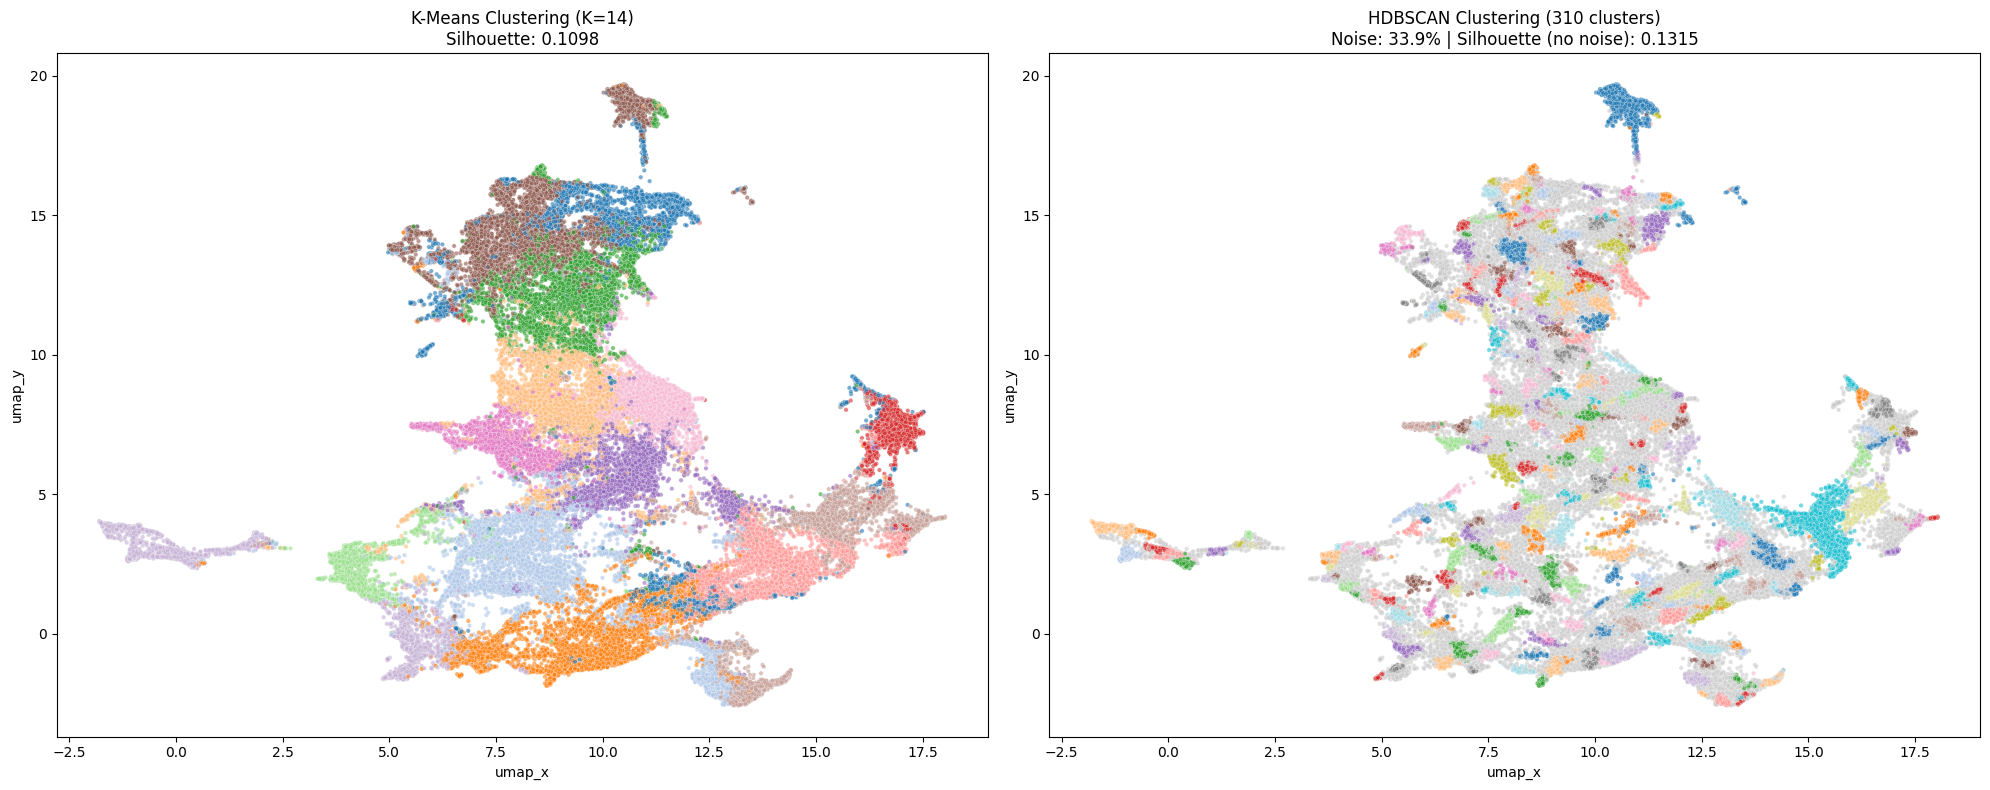

In [12]:
print("Projecting to 2D for visualization...")
umap_2d_model = umap.UMAP(n_neighbors=best_n_neighbors, n_components=2, min_dist=0.1, metric='cosine', random_state=42)
embeddings_2d = umap_2d_model.fit_transform(final_embeddings)

df['umap_x'] = embeddings_2d[:, 0]
df['umap_y'] = embeddings_2d[:, 1]

# Set up the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot K-Means ---
sns.scatterplot(
    data=df, x='umap_x', y='umap_y', 
    hue='kmeans_cluster', palette='tab20', 
    s=10, alpha=0.6, ax=ax1, legend=False
)
ax1.set_title(f'K-Means Clustering (K={K_CLASSIC})\nSilhouette: {kmeans_silhouette:.4f}')

# --- Plot HDBSCAN ---
# Custom palette so noise points (-1) are light gray
palette = sns.color_palette('tab20', n_clusters)
color_map = {cluster_id: palette[i % len(palette)] for i, cluster_id in enumerate(sorted(list(set(hdbscan_labels) - {-1})))}
color_map[-1] = (0.8, 0.8, 0.8) # Gray for noise

sns.scatterplot(
    data=df, x='umap_x', y='umap_y', 
    hue='hdbscan_cluster', palette=color_map, 
    s=10, alpha=0.6, ax=ax2, legend=False
)
ax2.set_title(f'HDBSCAN Clustering ({n_clusters} clusters)\nNoise: {noise_percent:.1f}% | Silhouette (no noise): {hdbscan_silhouette:.4f}')

plt.tight_layout()
plt.show()

The grey areas in HDBSCAN clustering are parts of the noise detected. We can interpret the majority of the noise could be happening because of interdisciplinary productions.

## 4.4. Quantitative Comparison against Administrative Boundaries (Faculty)

Normalized Mutual Information (NMI) and Adjusted Rand Index (ARI) is used to see how closely the semantic clusters align with the university's administrative faculties.

Note: We injected the faculty name into the embeddings text, so the Modern Pipeline has a structural advantage compared to the Classic NLP baseline for this case

In [13]:
# Drop any rows where faculty might be null just in case
eval_df = df.dropna(subset=['faculty', 'kmeans_cluster', 'hdbscan_cluster']).copy()

# KMeans Metrics
kmeans_nmi = normalized_mutual_info_score(eval_df['faculty'], eval_df['kmeans_cluster'])
kmeans_ari = adjusted_rand_score(eval_df['faculty'], eval_df['kmeans_cluster'])

# HDBSCAN Metrics (we filter out noise points for a fair evaluation of the formed clusters)
hdbscan_eval_df = eval_df[eval_df['hdbscan_cluster'] != -1]
hdbscan_nmi = normalized_mutual_info_score(hdbscan_eval_df['faculty'], hdbscan_eval_df['hdbscan_cluster'])
hdbscan_ari = adjusted_rand_score(hdbscan_eval_df['faculty'], hdbscan_eval_df['hdbscan_cluster'])

print("--- Alignment with Administrative Faculties ---")
print(f"K-Means -> NMI: {kmeans_nmi:.4f} | ARI: {kmeans_ari:.4f}")
print(f"HDBSCAN -> NMI: {hdbscan_nmi:.4f} | ARI: {hdbscan_ari:.4f}")

--- Alignment with Administrative Faculties ---
K-Means -> NMI: 0.0004 | ARI: 0.0001
HDBSCAN -> NMI: 0.0068 | ARI: -0.0000


### 4.4.1. Interdisciplinary Mixing Analysis

The NMI and ARI scores against the faculty column are virtually zero. This proves our core hypothesis: Academic research at UNAL is more flexible than rigid administrative boundaries.

To demonstrate that this is not simply a mistake, here is the composition of one of the largest semantic clusters discovered by HDBSCAN to check whether it covers several faculties.

In [14]:
# Find the largest non-noise cluster
largest_cluster_id = df[df['hdbscan_cluster'] != -1]['hdbscan_cluster'].value_counts().idxmax()
cluster_df = df[df['hdbscan_cluster'] == largest_cluster_id]

print(f"Composition of Largest Semantic Cluster (Cluster {largest_cluster_id}) by Faculty:")
faculty_counts = cluster_df['faculty'].value_counts()
print(faculty_counts.head(10))

print("\n--- Sampling 1 random record per Faculty from the Largest Cluster ---")
# Sample from the faculties in this cluster to check semantic coherence
for faculty in faculty_counts.index:
    sample_row = cluster_df[cluster_df['faculty'] == faculty].sample(1, random_state=42).iloc[0]
    embeddings_text = str(sample_row.get('embeddings_text', 'No Title'))
    print(f"\n{embeddings_text}")

Composition of Largest Semantic Cluster (Cluster 58) by Faculty:
faculty
Ciencias               900
Medicina               533
Ingeniería             408
Ciencias Humanas       301
Artes                  172
Derecho                116
Ciencias Agrarias      112
Ciencias Económicas    105
Veterinaria             81
Enfermería              73
Name: count, dtype: int64

--- Sampling 1 random record per Faculty from the Largest Cluster ---

[Ciencias] Ponencias en eventos especializados: Aplicacion de microextraccion en fase solida (spme) con cromatografia de gases/ espectrometria de masas (gcms) en la identificacion de tolueno en muestras de sangre entera

[Medicina] Tesis Especialización: Abordaje endoscópico del nervio mediano en el tercio proximal del antebrazo. Introducción: El tratamiento quirúrgico del síndrome pronador clásicamente ha requerido de un abordaje abierto en la fosa cubital que deja una gran cicatriz, técnicas endoscópicas iniciales requerían abordajes de 4 cm en promed

### 4.4.2. Conclusion on Interdisciplinary Mixing

The sampled records demonstrate that while the cluster encompasses a wide array of faculties, there is a recurring underlying macro-theme related to society, public policy, human rights, and urban/rural dynamics (e.g., patient autonomy in Law, urban recovery in Arts, agricultural taxation impacts in Economics). 

The broad nature of this cluster indicates that HDBSCAN has identified a massive interdisciplinary "hub". This confirms the hypothesis that semantic topics do not strictly adhere to administrative boundaries, explaining the near-zero NMI score. To achieve higher granularity and break this macro-topic into more specific sub-disciplines, adjusting the `min_cluster_size` parameter to a lower threshold or applying hierarchical sub-clustering could be explored in future iterations.

## 4.5. Latent Expertise Extraction (c-TF-IDF)

To prove that the clusters formed by HDBSCAN and K-Means are semantically coherent, top keywords per cluster are extracted using Class-based TF-IDF (c-TF-IDF).
Since the corpus is predominantly Spanish (>70%) with a significant English representation, the stopword removal must combine both languages to correctly denoise the topics. We consolidate the logic into a reusable function for both clustering approaches.

In [15]:
# Download the stopwords dataset if you haven't run this on your machine before
nltk.download('stopwords')

# 0. Sample language distribution to justify custom stopwords
language_dist = df['language'].value_counts(normalize=True) * 100
print("--- Language Distribution in the Corpus ---")
print(language_dist.head(5).round(2).astype(str) + "%")

# Define custom combined stopwords list for both models
custom_stopwords = stopwords.words('spanish') + stopwords.words('english')
# Add domain-specific fluff words to prevent generic topics
custom_stopwords.extend([
    'colombia', 'estudio', 'analisis', 'resultados', 'study', 'analysis', 'results', 'nacional', 'universidad', 'bogota'
])

def extract_cluster_keywords(df, cluster_col, text_col, stop_words, top_n=10, min_df=5, max_df=0.90):
    """
    Groups documents by cluster and applies c-TF-IDF to extract top distinctive keywords per cluster.
    Filters out noise clusters (-1) if they exist.
    """
    print(f"\nGrouping documents by {cluster_col}...")
    if -1 in df[cluster_col].unique():
        docs_per_cluster = df[df[cluster_col] != -1].groupby(cluster_col)[text_col].apply(' '.join).reset_index()
    else:
        docs_per_cluster = df.groupby(cluster_col)[text_col].apply(' '.join).reset_index()

    vectorizer = CountVectorizer(max_df=max_df, min_df=min_df, stop_words=stop_words)
    X = vectorizer.fit_transform(docs_per_cluster[text_col])
    words = vectorizer.get_feature_names_out()

    ctfidf_transformer = ClassTfidfTransformer()
    c_tfidf_matrix = ctfidf_transformer.fit_transform(X)

    cluster_keywords = {}
    for i, cluster_id in enumerate(docs_per_cluster[cluster_col]):
        row = c_tfidf_matrix.getrow(i).toarray()[0]
        top_indices = row.argsort()[-top_n:][::-1]
        keywords = [words[idx] for idx in top_indices]
        cluster_keywords[cluster_id] = keywords

    return cluster_keywords

# --- 1. HDBSCAN Cluster Keywords ---
# We use the clean 'classic_text' here because we want words, not the structural metadata!
print("\nExtracting keywords for HDBSCAN clusters...")
cluster_keywords = extract_cluster_keywords(
    df=df, 
    cluster_col='hdbscan_cluster', 
    text_col='classic_text', 
    stop_words=custom_stopwords, 
    top_n=10, 
    min_df=2, 
    max_df=0.95
)

# Display the keywords for the top 5 largest HDBSCAN clusters
cluster_sizes_hdbscan = df[df['hdbscan_cluster'] != -1]['hdbscan_cluster'].value_counts().head(5)

print("\n--- Top Keywords for the 5 Largest Semantic Clusters (HDBSCAN) ---")
for cluster_id, size in cluster_sizes_hdbscan.items():
    print(f"\nCluster {cluster_id} (Size: {size} documents):")
    print(", ".join(cluster_keywords[cluster_id]))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/fvalderramab/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- Language Distribution in the Corpus ---
language
Español       61.3%
Inglés       37.23%
Portugués     0.63%
Francés       0.39%
Alemán        0.24%
Name: proportion, dtype: object

Extracting keywords for HDBSCAN clusters...

Grouping documents by hdbscan_cluster...



--- Top Keywords for the 5 Largest Semantic Clusters (HDBSCAN) ---

Cluster 58 (Size: 2871 documents):
specie, ciudad, cultural, derecho, cuidado, espacio, respuesta, persona, decisión, zona

Cluster 0 (Size: 2430 documents):
specie, cell, energy, complex, distribution, molecular, consider, mass, agua, production

Cluster 260 (Size: 1252 documents):
cell, virus, production, specie, comunidad, interaction, stress, temperature, film, rate

Cluster 57 (Size: 1033 documents):
ambiental, diagnóstico, agua, derecho, oral, care, aba, role, política, energy

Cluster 259 (Size: 998 documents):
sorbitol, prueba, concentración, propiedad, decay, muestra, agua, aprendizaje, instrumento, rural


In [16]:
# --- 2. K-Means Cluster Keywords ---
print("Extracting keywords for KMeans clusters...")
kmeans_keywords = extract_cluster_keywords(
    df=df, 
    cluster_col='kmeans_cluster', 
    text_col='classic_text', 
    stop_words=custom_stopwords, 
    top_n=12, 
    min_df=5, 
    max_df=0.90
)

# Display results for K-Means
cluster_sizes_kmeans = df['kmeans_cluster'].value_counts()

print("\n--- Top Keywords for Semantic K-Means (K=14) ---")
for cluster_id, size in cluster_sizes_kmeans.items():
    print(f"\nCluster {cluster_id} (Size: {size} docs):")
    print(", ".join(kmeans_keywords[cluster_id]))

Extracting keywords for KMeans clusters...

Grouping documents by kmeans_cluster...

--- Top Keywords for Semantic K-Means (K=14) ---

Cluster 10 (Size: 11507 docs):
sperm, wheat, glaucoma, sutura, ercp, nps, bracket, testosterone, flour, febrile, pneumococcal, asfalto

Cluster 1 (Size: 9961 docs):
ghrelin, patio, zikv, nps, denv, eim, resorcinarene, valerián, groundwater, serpiente, copd, caucho

Cluster 4 (Size: 9526 docs):
hbv, cmv, pectin, eno, pha, sativo, rbc, speciation, speaker, qtls, odp, remodeling

Cluster 2 (Size: 9279 docs):
copd, bronchiolitis, syphili, bpm, glaucoma, cof, nietzsche, corneal, coagulación, fare, genipin, cys

Cluster 3 (Size: 8366 docs):
semiología, tigrillo, ctpa, cuento, tabio, quito, citric, igf, mies, clón, osteoclast, citrate

Cluster 0 (Size: 7799 docs):
platelet, pág, lockdown, yuwe, herbicida, videojuego, hematopoietic, leucocytozoon, oclusal, histolytica, reconnection, lgbti

Cluster 7 (Size: 7434 docs):
lactose, acupuntura, nietzsche, pard, depre

# 5. Export Results
The clustering labels, evaluation metrics, and top terms are exported for comparative analysis by the final evaluator team member.

In [17]:
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 5.1. Export Labels
labels_output_path = OUTPUT_DIR / "05_modern_clustering_labels.parquet"

if "original_row_index" not in df.columns:
    df["original_row_index"] = df.index

export_columns = [
    "original_row_index",
    "kmeans_cluster",
    "hdbscan_cluster"
]

export_df = df[export_columns].rename(columns={
    "kmeans_cluster": "cluster_mod_kmeans",
    "hdbscan_cluster": "cluster_mod_hdbscan"
})

export_df.to_parquet(labels_output_path, index=False)
print(f"Modern clustering labels exported to: {labels_output_path}")

# 5.2. Export Metrics
metrics_output_path = OUTPUT_DIR / "05_modern_clustering_metrics.csv"

metrics_data = {
    "model": ["Modern KMeans", "HDBSCAN"],
    "silhouette": [kmeans_silhouette, hdbscan_silhouette],
    "calinski_harabasz": [kmeans_calinski, hdbscan_calinski],
    "davies_bouldin": [kmeans_davies, hdbscan_davies],
    "nmi": [kmeans_nmi, hdbscan_nmi],
    "ari": [kmeans_ari, hdbscan_ari]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(metrics_output_path, index=False)
print(f"Modern clustering metrics exported to: {metrics_output_path}")

# 5.3. Export Top Terms (HDBSCAN c-TF-IDF)
top_terms_hdbscan_path = OUTPUT_DIR / "05_modern_hdbscan_top_terms.csv"
top_terms_records = []
for cluster_id, words_list in cluster_keywords.items():
    top_terms_records.append({
        "cluster_id": cluster_id,
        "top_terms": ", ".join(words_list)
    })
    
top_terms_df = pd.DataFrame(top_terms_records)
top_terms_df.to_csv(top_terms_hdbscan_path, index=False)
print(f"HDBSCAN top terms exported to: {top_terms_hdbscan_path}")

# 5.4. Export Top Terms (K-Means c-TF-IDF)
top_terms_kmeans_path = OUTPUT_DIR / "05_modern_kmeans_top_terms.csv"
top_terms_records_kmeans = []
for cluster_id, words_list in kmeans_keywords.items():
    top_terms_records_kmeans.append({
        "cluster_id": cluster_id,
        "top_terms": ", ".join(words_list)
    })
    
top_terms_df_kmeans = pd.DataFrame(top_terms_records_kmeans)
top_terms_df_kmeans.to_csv(top_terms_kmeans_path, index=False)
print(f"K-Means top terms exported to: {top_terms_kmeans_path}")

Modern clustering labels exported to: ../outputs/05_modern_clustering_labels.parquet
Modern clustering metrics exported to: ../outputs/05_modern_clustering_metrics.csv
HDBSCAN top terms exported to: ../outputs/05_modern_hdbscan_top_terms.csv
K-Means top terms exported to: ../outputs/05_modern_kmeans_top_terms.csv


# 6. Brief interpretation and future work

The modern baseline fundamentally upgraded the text representation from sparse lexical matching (TF-IDF) to dense semantic vectors using `jina-embeddings-v5-text-small`. This effectively mitigated the cross-lingual semantic drift present in the bilingual (Spanish/English) corpus and captured the actual contextual meaning of the academic abstracts. 

To enable a direct comparison with the classical pipeline, **K-Means** was executed using the exact same number of clusters ($k=14$). The modern embeddings outperformed the classical representation across internal metrics, yielding a significantly lower Davies-Bouldin score and a much higher Silhouette score, proving that semantic vectors create tighter, more cohesive groupings than word counts.

Furthermore, **UMAP + HDBSCAN** was introduced to allow the data's natural topology to dictate the number of clusters. This density-based approach successfully identified highly granular research niches. The near-zero NMI and ARI scores against the administrative `faculty` column empirically proved our core hypothesis: academic research at the university is deeply interdisciplinary and consistently transcends rigid administrative boundaries. 

**Pathways for SOTA Improvement (Future Iterations):**

While this pipeline establishes a robust modern baseline, the ~34% noise rate identified by HDBSCAN highlights the limitations of rigid density-based clustering. Many of these "noise" points are actually highly valuable, multi-disciplinary abstracts that sit between distinct clusters. Future iterations to upgrade this pipeline to the 2025-2026 State-of-the-Art could include:

* **Advanced Semantic Representation:** Upgrading the embedding model to **Qwen3-Embedding-8B**. This would allow for instruction-aware encoding (tailoring the latent space specifically for expert profiling) and native 32,000-token context windows to ensure massive historical publication records are never truncated.
* **Overcoming the Single-Topic Assumption:** Replacing c-TF-IDF and HDBSCAN with **Semantic Component Analysis (SCA)**. By mathematically projecting documents into multiple semantic components, SCA can assign secondary and tertiary topics to a single abstract, virtually eliminating the 34% noise rate caused by interdisciplinary blurring.
* **Optimal Transport Taxonomy:** Integrating **Hierarchical Contrastive Optimal Transport (HiCOT)** to frame the document-to-topic assignment as a Wasserstein distance problem. This would strictly prevent "topic collapse" and allow the system to map complex, hierarchical intersections of faculty expertise with near-perfect topic diversity.